# 시계열 데이터
- 일정한 시간 간격에 따라 순차적으로 기록된 데이터
ex) google 주가
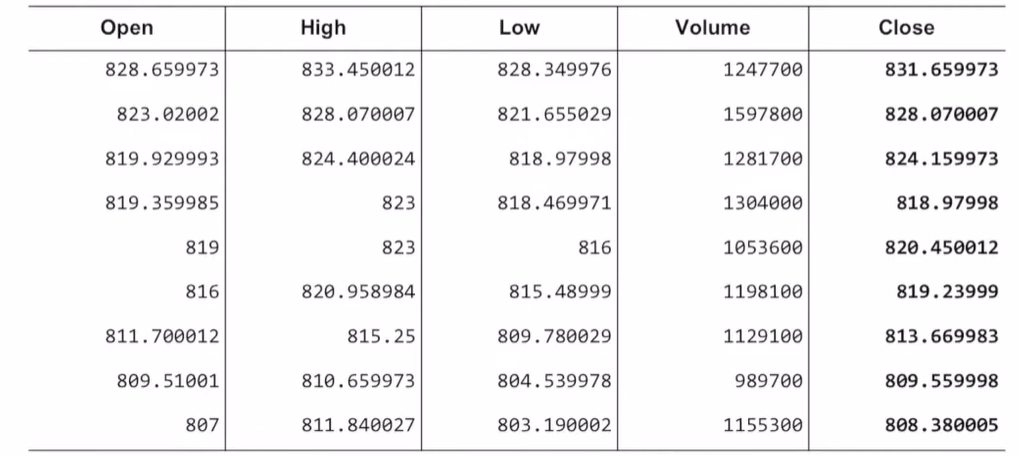
- input : 7일간의 데이터
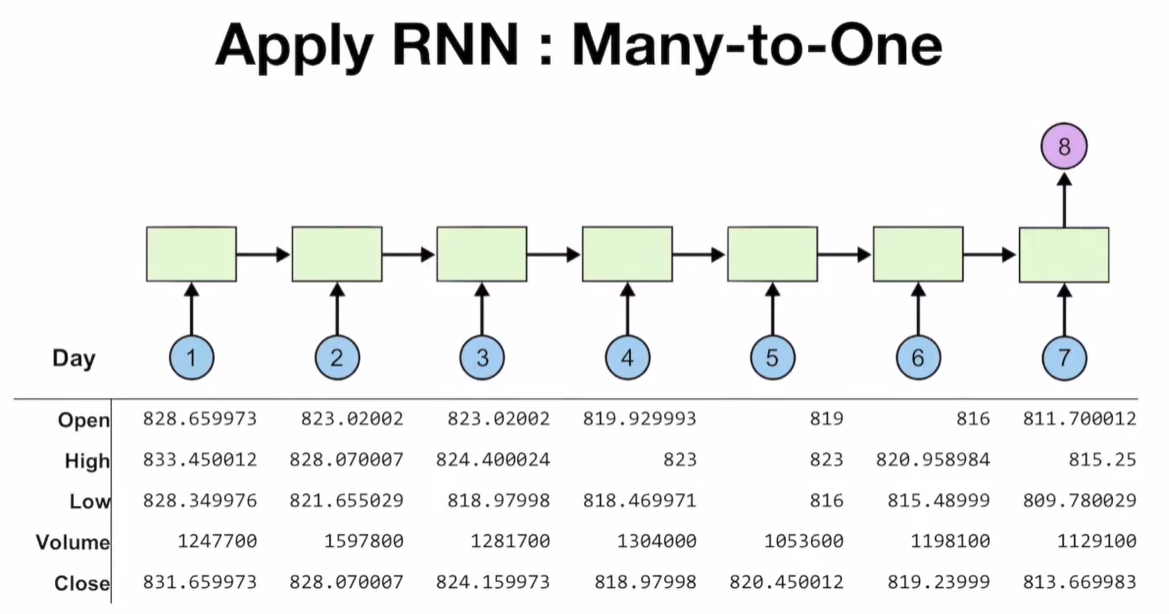
- output : 8일차의 데이터
- **"7일간의 데이터 흐름(Many)을 RNN이 분석하고, 그 요약본을 FC 레이어에 던져주면, FC가 그걸 계산해서 내일의 종가 딱 하나(One)를 맞추는 구조"**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
torch.manual_seed(0)

In [ ]:
# hyperparameters
seq_length = 7 # 7일 데이터
data_dim = 5 # 5개 디멘션 
hidden_dim = 10
output_dim = 1 # fc로 하나. 
learning_rate = 0.01
iterations = 500

xy = np.loadtxt("data-02-stock_daily.csv", delimiter=",")
xy = xy[::-1] # reverse order

train_size = int(len(xy) * 0.7) # 70%가 train set
train_set = xy[0:train_size]
test_set = xy[train_size - seq_length:] # 나머지 test

### Min-Max Scaling (정규화 기법)
$$x_{scaled} = \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon}$$
- 데이터의 범위를 0과 1 사이로 압축해주는 정규화 기법. 
- 데이터들의 전체 단위(scale)를 통일하기 위해 필수적으로 사용하는 과정. 

In [4]:
# scaling function for input data
def minmax_scaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)

In [5]:
# make dataset to input

def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(time_series) - seq_length):
        _x = time_series[i:i + seq_length, :]
        _y = time_series[i + seq_length, [-1]] # next close price
        print(_x, "->", _y)
        dataX.append(_x)
        dataY.append(_y)
    return np.array(dataX), np.array(dataY)

In [7]:
train_set = minmax_scaler(train_set)
test_set = minmax_scaler(test_set)

trainX, trainY = build_dataset(train_set, seq_length)
testX, testY = build_dataset(test_set, seq_length)

trainX_tensor = torch.FloatTensor(trainX)
trainY_tensor = torch.FloatTensor(trainY)

testX_tensor = torch.FloatTensor(testX)
testY_tensor = torch.FloatTensor(testY)

[[2.53065005e-01 2.45070946e-01 2.33983013e-01 4.66075063e-04
  2.32039537e-01]
 [2.29604344e-01 2.39728912e-01 2.54567488e-01 2.98467300e-03
  2.37426004e-01]
 [2.49235485e-01 2.41668347e-01 2.48338465e-01 2.59926478e-04
  2.26793771e-01]
 [2.21013472e-01 2.46602207e-01 2.54710558e-01 0.00000000e+00
  2.62668213e-01]
 [3.63433750e-01 3.70389834e-01 2.67168820e-01 1.24764709e-02
  2.62104984e-01]
 [2.59447607e-01 3.10673693e-01 2.74113862e-01 4.56323339e-01
  2.71751238e-01]
 [2.76008123e-01 2.78314538e-01 1.98470360e-01 5.70171136e-01
  1.78104626e-01]] -> [0.16053714]
[[2.29604344e-01 2.39728912e-01 2.54567488e-01 2.98467300e-03
  2.37426004e-01]
 [2.49235485e-01 2.41668347e-01 2.48338465e-01 2.59926478e-04
  2.26793771e-01]
 [2.21013472e-01 2.46602207e-01 2.54710558e-01 0.00000000e+00
  2.62668213e-01]
 [3.63433750e-01 3.70389834e-01 2.67168820e-01 1.24764709e-02
  2.62104984e-01]
 [2.59447607e-01 3.10673693e-01 2.74113862e-01 4.56323339e-01
  2.71751238e-01]
 [2.76008123e-01 2.7831

In [ ]:
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, layers):
        super(Net, self).__init__()

        # LSTM 사용 
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim, bias=True)

    def forward(self, x):
        x, _status = self.rnn(x) # 7일치 데이터를 LSTM에 넣어 날짜별 요약본 만들기
        x = self.fc(x[:, -1]) # 그 중 마지막 날(7일 차)의 요약 정보만 손에 쥐어 fc레이어에 넣어 종가 숫자 1개로 바꾸기.
        # x[:, -1] -> 전체 묶음 중 각 줄의 가장 마지막 놈만 가져 옴.
        # ex) (32, 7, 64) -> (32, 64) 날짜 차원 사라짐
        # :는 지문 전체(batch)를 다 읽으라는 뜻이고
        # -1은 지문의 마지막 문장만 보겠다는 것. 
        return x

net = Net(data_dim, hidden_dim, output_dim, 1)

# loss & optimizer setting
criterion = torch.nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

In [ ]:
for i in range(iterations):
    optimizer.zero_grad()
    outputs = net(trainX_tensor)

    loss = criterion(outputs, trainY_tensor)
    loss.backward()
    optimizer.step()
    print(i, loss.item())

plt.plot(testY)
plt.plot(net(testX_tensor).data.numpy())
plt.legend(['original', 'prediction'])
plt.show()